In [1]:
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')
import sys
sys.path.append('/Users/apple/Desktop/SCP_Projects/SCP_Microglia/code/scDIA')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import scanpy as sc
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scdia as sd

sc.settings.verbosity = 3

# set data, figure, and results directories
data_dir = '/Volumes/SU700/scpMS_data/scpMS_microglia/'
fig_dir = 'SCP_Microglia/figures/1_3_preprocessing/'
results_dir = 'SCP_Microglia/results/1_3_preprocessing/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

In [2]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

In [5]:
adata_1c_maxlfq_gene = sc.read_h5ad('SCP_Microglia/results/1_2_qc/scp_MG_1c_maxlfq_gene_after_qc.h5ad')

In [3]:
phagosome_proteins = pd.read_csv('SCP_Microglia/results/phagosome_proteins.txt', header=None)[0].tolist()
len(phagosome_proteins)

365

In [6]:
len(adata_1c_maxlfq_gene.var_names.intersection(phagosome_proteins))

320

In [8]:
# export exo proteins
phagosome_proteins_in_data = adata_1c_maxlfq_gene.var_names.intersection(phagosome_proteins)
pd.DataFrame({'protein': list(phagosome_proteins_in_data)}).to_csv(os.path.join(results_dir, 'phagosome_proteins_in_data.txt'), index=False, header=False)

In [27]:
adata_1c_maxlfq_exo= adata_1c_maxlfq_gene[:, adata_1c_maxlfq_gene.var_names.isin(phagosome_proteins)].copy()

adata_1c_maxlfq_exo.write_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene_after_qc_exo.h5ad', compression='gzip')

In [ ]:

from gseapy import enrich, get_library

go_cc = get_library(name='GO_Cellular_Component_2023', organism='mouse')

enr = enrich(
    gene_list=list(phagosome_proteins_in_data), 
    gene_sets=go_cc, 
    background=list(adata_1c_maxlfq_gene.var_names)
)

In [ ]:
results = enr.results
filtered_results = results[results['Adjusted P-value'] < 0.01]

filtered_results = filtered_results.sort_values('Adjusted P-value')
filtered_results['Term'] = filtered_results['Term'].str.split('\(GO').str[0]  

In [15]:
filtered_results['-log10(Adjusted P-value)'] = -np.log10(filtered_results['Adjusted P-value'])

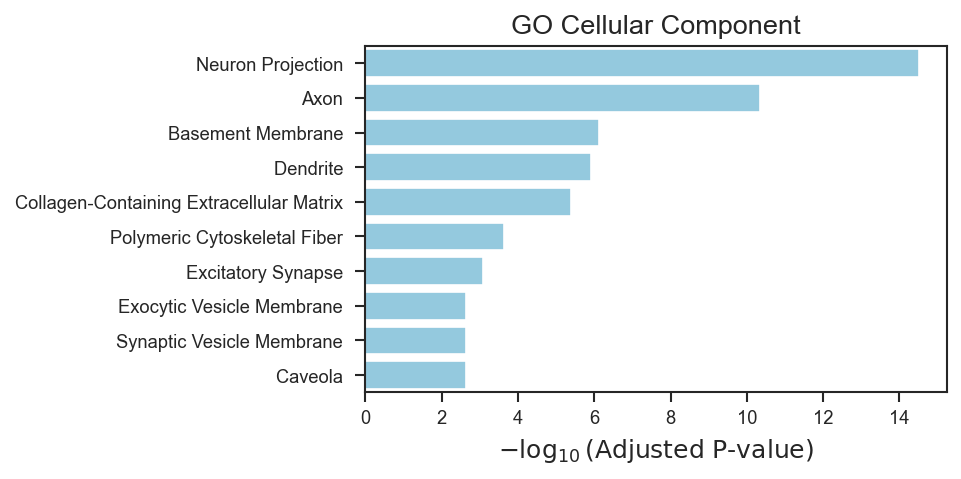

In [51]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(
    data=filtered_results.head(10), 
    x='-log10(Adjusted P-value)', 
    y='Term', 
    color='skyblue',
    ax=ax
)
ax.set_xlabel(r'$-\log_{10}(\text{Adjusted P-value})$', fontsize=12)
ax.set_ylabel('')

plt.title('GO Cellular Component', fontsize=13)
plt.savefig(os.path.join(fig_dir, 'phagosome_proteins_go_cc_enrichment.pdf'))

### Plot comparison of exo genes in scp and scRNA

In [28]:
adata_1c_maxlfq_exo

AnnData object with n_obs × n_vars = 3068 × 320
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity'

In [29]:
sd.qc.calculate_feature_qc_metrics(adata_1c_maxlfq_exo, inplace=True)

In [44]:
var_df_scp = adata_1c_maxlfq_exo.var.sort_values('pct_detected_cells', ascending=False)
top10_genes = var_df_scp.head(11).index.to_list()

In [37]:
hammond_rna = sc.read_h5ad(data_dir + 'scRNA-seq/Hammond_et-al_Immunity_2019.h5ad')

In [38]:
hammond_rna.X = hammond_rna.layers['counts_RNA'].copy()
del hammond_rna.layers['counts_RNA']

sc.pp.filter_genes(hammond_rna, min_cells=3)
sc.pp.calculate_qc_metrics(hammond_rna, inplace=True, log1p=False, percent_top=None)

sc.pp.normalize_total(hammond_rna)
sc.pp.log1p(hammond_rna, base=2)

filtered out 2893 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)


In [46]:
hammond_rna.var['pct_detected_cells'] = 100 - hammond_rna.var['pct_dropout_by_counts']
top_genes = [gene for gene in top10_genes if gene in hammond_rna.var_names]

In [47]:
top_var_df_rna = hammond_rna.var.loc[top_genes, 'pct_detected_cells']
top_var_df_scp = var_df_scp.loc[top_genes, 'pct_detected_cells']

comparison_df = pd.DataFrame({
    'Gene': top_genes,
    'scRNA-seq': top_var_df_rna.values,
    'scp': top_var_df_scp.values
})

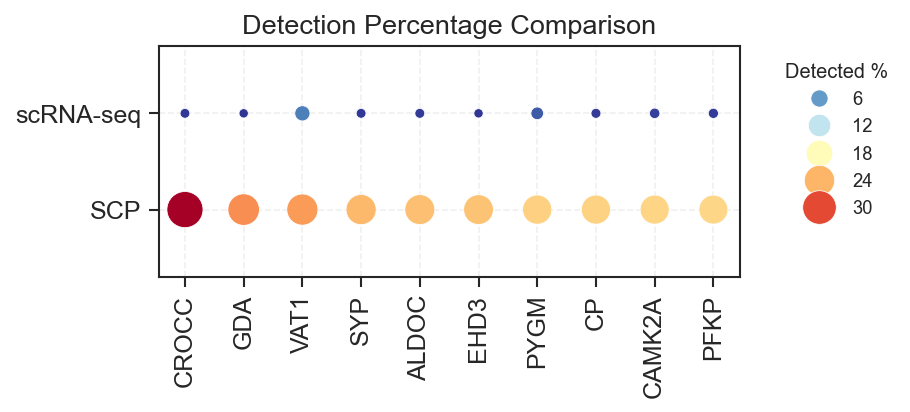

In [49]:
plot_df = comparison_df.melt(id_vars='Gene', var_name='Modality', value_name='Percentage')

fig, ax = plt.subplots(figsize=(5, 2))
sns.scatterplot(
    data=plot_df,
    x='Gene',
    y='Modality',
    size='Percentage',
    hue='Percentage',
    sizes=(20, 300),
    palette='RdYlBu_r',
    ax=ax
)

ax.set_ylabel('')
ax.set_xlabel('')
ax.set_yticklabels(['scRNA-seq', 'SCP'], fontsize=12)
# set all tick labels to 90 degree rotation and upper case
ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()], rotation=90, fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Detected %', frameon=False)
ax.set_title('Detection Percentage Comparison', fontsize=13)
ax.set_ymargin(0.7)
ax.grid(True, linestyle='--', alpha=0.3)

plt.savefig(fig_dir + 'gene_detection_comparison.pdf', dpi=300, bbox_inches='tight')

In [20]:
adata_1c_maxlfq_gene = adata_1c_maxlfq_gene[:, ~adata_1c_maxlfq_gene.var_names.isin(phagosome_proteins)].copy()
adata_1c_maxlfq_gene

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity'

In [21]:
batch_key = 'prepare_date'
adata_1c_maxlfq_gene = adata_1c_maxlfq_gene[adata_1c_maxlfq_gene.obs.sort_values(by=batch_key).index].copy()

In [22]:
adata_maxlfq_R = adata_1c_maxlfq_gene.copy()
adata_maxlfq_R.layers['counts'] = adata_maxlfq_R.X.copy()
adata_maxlfq_R.X = None
adata_maxlfq_R.write_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene_after_qc_remove_exo_toR.h5ad')

In [23]:
adata_1c_maxlfq_gene.layers['raw_matrix'] = adata_1c_maxlfq_gene.X.copy()
    
sd.pp.normalize_total(adata_1c_maxlfq_gene, target_sum=1e6)
# normalize(adata, method='median', input_layer=None, output_layer=None, inplace=True)
sc.pp.log1p(adata_1c_maxlfq_gene, base=2)

adata_1c_maxlfq_gene.layers['log2_total_normalized'] = adata_1c_maxlfq_gene.X.copy()

In [24]:
sc.pp.highly_variable_genes(
    adata_1c_maxlfq_gene,
    layer = 'raw_matrix',
    n_top_genes = 2000,
    flavor = 'seurat_v3',
    batch_key = 'prepare_date'
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [25]:
sc.tl.pca(adata_1c_maxlfq_gene, use_highly_variable=True, svd_solver='arpack')

sc.pp.neighbors(adata_1c_maxlfq_gene, n_pcs=20, n_neighbors=20)

sc.tl.umap(adata_1c_maxlfq_gene, min_dist=0.3, spread=1.0)

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


In [26]:
log_normalized_layer = adata_1c_maxlfq_gene.layers['log2_total_normalized']
log_normalized_layer = np.where((log_normalized_layer == -np.inf) | (log_normalized_layer == 0), np.nan, log_normalized_layer)
log_normalized_fc_layer = log_normalized_layer - np.nanmean(log_normalized_layer, axis=0)

adata_1c_maxlfq_gene.layers['log2_total_normalized_fc_nan'] = log_normalized_fc_layer

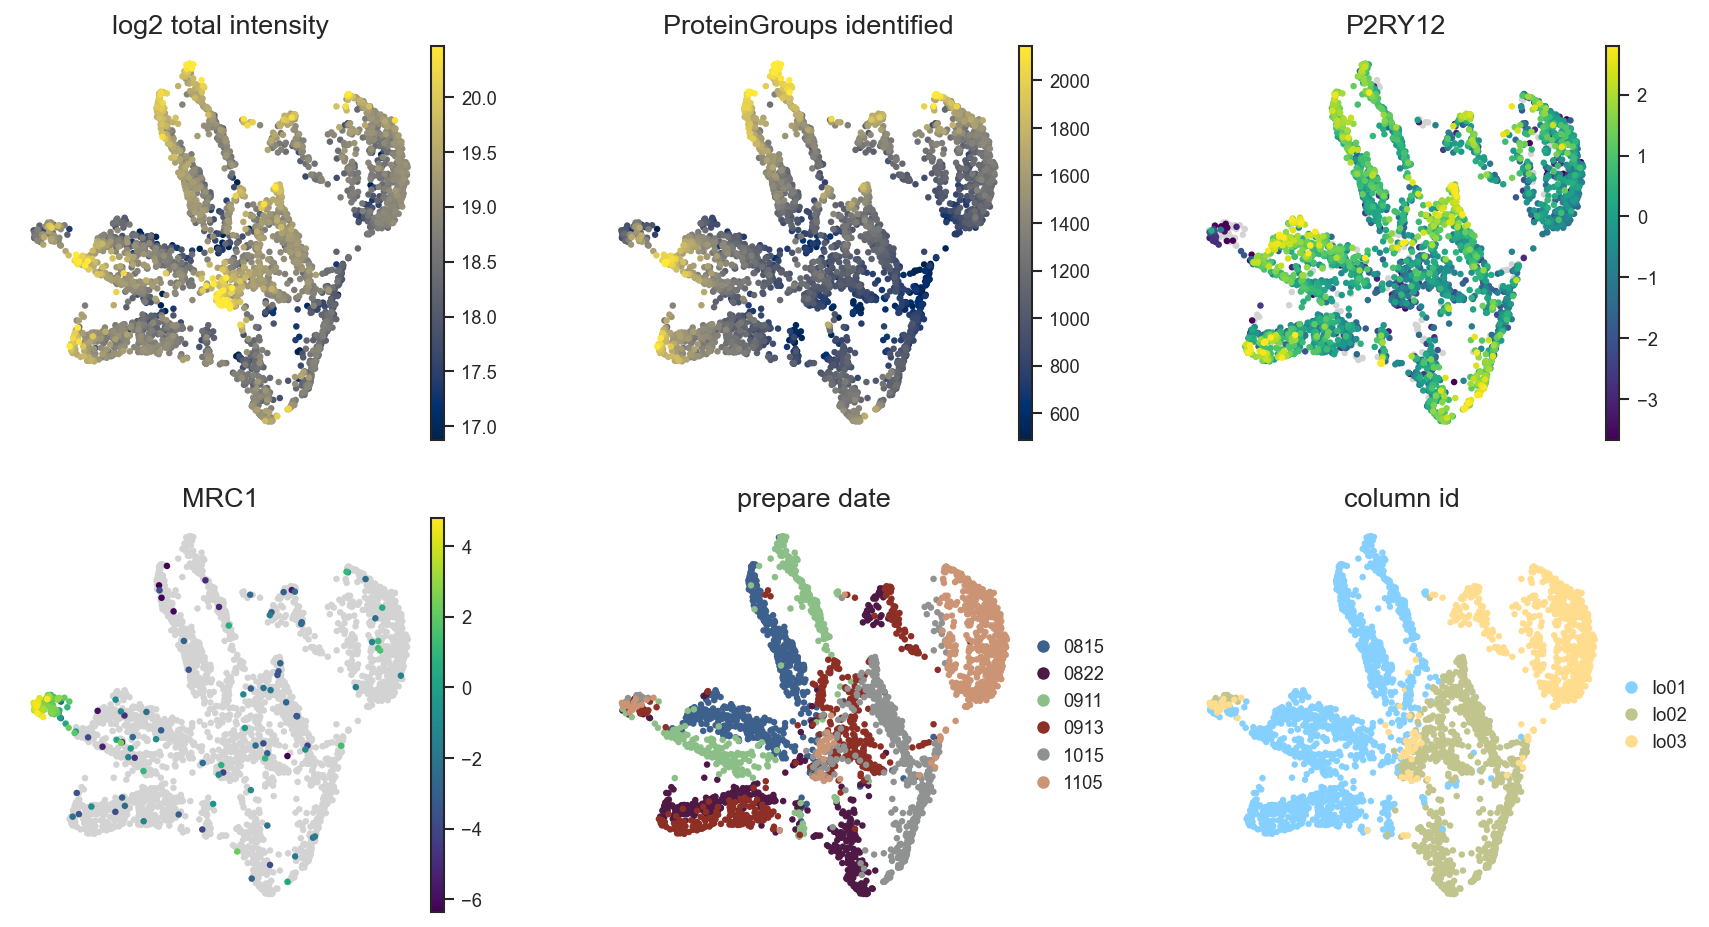

In [65]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.lines as mlines

# plot UMAP
plot_parameters = [
    'log2_total_intensity', 'ProteinGroups_identified', 'P2ry12', 'Mrc1', 'prepare_date', 'column_id'
]

plot_cmaps = {
    'log2_total_intensity': 'cividis',
    'ProteinGroups_identified': 'cividis',
    'Peptides_identified': 'cividis',
    'P2ry12': 'viridis',
    'Mrc1': 'viridis',
}

plot_color_palettes = {
    'prepare_date': ["#3e608d", "#4e1945", "#8cbf87", "#8d2f25", "#909291", "#cb9475"],
    'column_id': ["#85D0FF", "#C2C48D", "#FFDC8E"],
    'brain_region': ["#ACD6EC", "#F5A889"],
    'age': ["#000000", "#2C939A", "#A6A3A4"]
}


fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.flatten()

for i, parameter in enumerate(plot_parameters):

    cmap = plot_cmaps.get(parameter, None)
    palette = plot_color_palettes.get(parameter, None)
    
    is_categorical = parameter in ['prepare_date', 'column_id']
    
    sc.pl.umap(
        adata_1c_maxlfq_gene,
        color=parameter,
        cmap=cmap,
        show=False,
        frameon=False,
        title=None,
        palette=palette,
        ax=axes[i],
        layer='log2_total_normalized_fc_nan',
        vmin='p1',
        vmax='p99',
        legend_loc='none' if is_categorical else 'right margin'
    )
    
    axes[i].set_title(' '.join(parameter.split('_')).upper() if parameter in ['Mrc1', 'P2ry12'] else ' '.join(parameter.split('_')), fontsize=13)
    # Manually allocate same spacing as colorbars to make the legends neatly align
    if is_categorical:
        divider = make_axes_locatable(axes[i])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cax.axis('off')
        
        obs_col = adata_1c_maxlfq_gene.obs[parameter]
        if hasattr(obs_col, "cat"):
            cats = obs_col.cat.categories
        else:
            cats = sorted(obs_col.dropna().astype(str).unique())
            
        handles = [mlines.Line2D([], [], color='w', marker='o', markerfacecolor=palette[k], markersize=7) for k in range(len(cats))]
        cax.legend(handles, cats, loc='center left', bbox_to_anchor=(-1.2, 0.5), frameon=False, handletextpad=0.1)

plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.savefig(fig_dir + 'maxlfq_umap_by_qc_parameters.pdf', bbox_inches='tight', dpi=300)

In [15]:
adata_1c_maxlfq_gene.write_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene_after_qc_remove_exo.h5ad', compression='gzip')

In [14]:
adata_1c_maxlfq_gene

AnnData object with n_obs × n_vars = 3068 × 3979
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'prepare_date_colors', 'column_id_colors', 'age_colors', 'brain_region_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_matrix', 'log2_total_normalized', 'log2_total_normalized_fc_nan'
    obsp: 'distances', 'connectivities'

In [16]:
adata_1c_maxlfq_exo= adata_1c_maxlfq_gene[:, adata_1c_maxlfq_gene.var_names.isin(phagosome_proteins)].copy()

adata_1c_maxlfq_exo.write_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene_after_qc_exo.h5ad', compression='gzip')